# Hyperparamater tuning by grid-search

- search for the best hyperparameters maximizing the generalization performance of a predictive model.

In [1]:
import pandas as pd
adult_census = pd.read_csv("data/adult_data.csv")

In [3]:
target_name = "class"
target = adult_census[target_name]
target.head()

0    b'<=50K'
1    b'<=50K'
2     b'>50K'
3     b'>50K'
4    b'<=50K'
Name: class, dtype: object

In [4]:
data = adult_census.drop(columns=[target_name,"education-num"])
data.head()

,age,workclass,fnlwgt,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25.0,b'Private',226802.0,b'11th',b'Never-married',b'Machine-op-inspct',b'Own-child',b'Black',b'Male',0.0,0.0,40.0,b'United-States'
1,38.0,b'Private',89814.0,b'HS-grad',b'Married-civ-spouse',b'Farming-fishing',b'Husband',b'White',b'Male',0.0,0.0,50.0,b'United-States'
2,28.0,b'Local-gov',336951.0,b'Assoc-acdm',b'Married-civ-spouse',b'Protective-serv',b'Husband',b'White',b'Male',0.0,0.0,40.0,b'United-States'
3,44.0,b'Private',160323.0,b'Some-college',b'Married-civ-spouse',b'Machine-op-inspct',b'Husband',b'Black',b'Male',7688.0,0.0,40.0,b'United-States'
4,18.0,b'?',103497.0,b'Some-college',b'Never-married',b'?',b'Own-child',b'White',b'Female',0.0,0.0,30.0,b'United-States'


In [5]:
from sklearn.model_selection import train_test_split

data_train, data_test, target_train, target_test = train_test_split(
    data, target, random_state=42
)

In [6]:
from sklearn.compose import make_column_selector as selector

categorical_columns_selector = selector(dtype_include=object)
categorical_columns = categorical_columns_selector(data)

In [7]:
from sklearn.preprocessing import OrdinalEncoder

categorical_preprocessor = OrdinalEncoder(
    handle_unknown="use_encoded_value", unknown_value=-1
)

In [8]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    [("cat_preprocessor", categorical_preprocessor, categorical_columns)],
    remainder="passthrough",
)

In [9]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline

model = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "classifier",
            HistGradientBoostingClassifier(random_state=42, max_leaf_nodes=4),
        ),
    ]
)
model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat_preprocessor',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['workclass', 'education',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native-country'])])),
                ('classifier',
                 HistGradientBoostingClassifier(max_leaf_nodes=4,
                                                random_state=42))])

In [10]:
%%time
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__learning_rate": (0.01, 0.1, 1, 10),
    "classifier__max_leaf_nodes": (3, 10, 30),
}
model_grid_search = GridSearchCV(model, param_grid=param_grid, n_jobs=2, cv=2)
model_grid_search.fit(data_train, target_train)

CPU times: total: 11 s
Wall time: 15.9 s


C:\Users\KIIT0001\miniconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=2,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('cat_preprocessor',
                                                                         OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                        unknown_value=-1),
                                                                         ['workclass',
                                                                          'education',
                                                                          'marital-status',
                                                                          'occupation',
                                                                          'relationship',
                                                                          'race',
                                                                          'sex',
                                                                          'native-country'])])),
                                       ('classifier',
                                        HistGradientBoostingClassifier(max_leaf_nodes=4,
                                                                       random_state=42))]),
             n_jobs=2,
             param_grid={'classifier__learning_rate': (0.01, 0.1, 1, 10),
                         'classifier__max_leaf_nodes': (3, 10, 30)})

In [11]:
accuracy = model_grid_search.score(data_test, target_test)
print(
    f"The test accuracy score of the grid-searched pipeline is: {accuracy:.2f}"
)

The test accuracy score of the grid-searched pipeline is: 0.88


In [12]:
model_grid_search.predict(data_test.iloc[0:5])

array(["b'<=50K'", "b'<=50K'", "b'>50K'", "b'<=50K'", "b'>50K'"],
      dtype=object)

The `GridSearchCV` estimator takes a `param_grid` parameter which defines all hyperparameters and their associated values. The grid-search is in charge of creating all possible combinations and test them.

The number of combinations are equal to the product of the number of values to explore for each parameter (e.g. here 4 x 3 combinations). Thus, adding new parameters with their associated values to be explored become rapidly computationally expensive.

Once the grid-search is fitted, it can be used as any other predictor by calling `predict` and `predict_proba`. Internally, it uses the model with the best parameters found during `fit`.

In [13]:
cv_results = pd.DataFrame(model_grid_search.cv_results_).sort_values(
    "mean_test_score", ascending=False
)
cv_results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier__learning_rate,param_classifier__max_leaf_nodes,params,split0_test_score,split1_test_score,mean_test_score,std_test_score,rank_test_score
5,1.642777,0.085567,0.221349,0.005051,0.1,30,"{'classifier__learning_rate': 0.1, 'classifier...",0.867766,0.867649,0.867708,0.000058,1
4,1.199156,0.074911,0.233367,0.008592,0.1,10,"{'classifier__learning_rate': 0.1, 'classifier...",0.866729,0.866557,0.866643,0.000086,2
6,0.497636,0.102667,0.180095,0.037517,1.0,3,"{'classifier__learning_rate': 1, 'classifier__...",0.860559,0.861261,0.860910,0.000351,3
7,0.306485,0.031351,0.120550,0.001138,1.0,10,"{'classifier__learning_rate': 1, 'classifier__...",0.857993,0.861862,0.859927,0.001934,4
3,0.603204,0.034606,0.153087,0.004942,0.1,3,"{'classifier__learning_rate': 0.1, 'classifier...",0.852752,0.854272,0.853512,0.000760,5


In [14]:
# get the parameter names
column_results = [f"param_{name}" for name in param_grid.keys()]
column_results += ["mean_test_score", "std_test_score", "rank_test_score"]
cv_results = cv_results[column_results]

In [15]:
def shorten_param(param_name):
    if "__" in param_name:
        return param_name.rsplit("__", 1)[1]
    return param_name


cv_results = cv_results.rename(shorten_param, axis=1)
cv_results

,learning_rate,max_leaf_nodes,mean_test_score,std_test_score,rank_test_score
5,0.10,30,0.867708,0.000058,1
4,0.10,10,0.866643,0.000086,2
6,1.00,3,0.860910,0.000351,3
7,1.00,10,0.859927,0.001934,4
3,0.10,3,0.853512,0.000760,5
8,1.00,30,0.851547,0.001798,6
2,0.01,30,0.845541,0.002289,7
1,0.01,10,0.817832,0.001124,8
0,0.01,3,0.797166,0.000715,9
10,10.00,10,0.618080,0.124277,10


In [16]:
pivoted_cv_results = cv_results.pivot_table(
    values="mean_test_score",
    index=["learning_rate"],
    columns=["max_leaf_nodes"],
)

pivoted_cv_results

max_leaf_nodes,3,10,30
learning_rate,,,
0.01,0.797166,0.817832,0.845541
0.10,0.853512,0.866643,0.867708
1.00,0.860910,0.859927,0.851547
10.00,0.283476,0.618080,0.351642


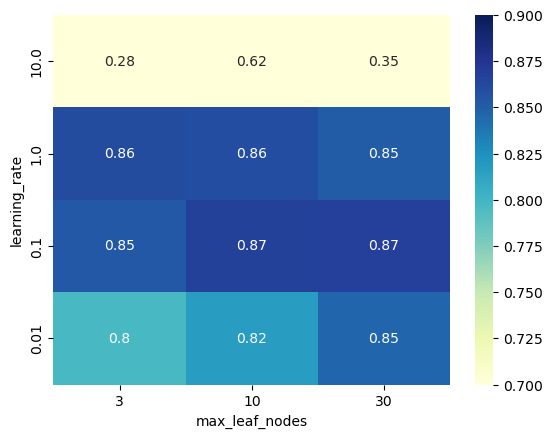

In [17]:
import seaborn as sns

ax = sns.heatmap(
    pivoted_cv_results, annot=True, cmap="YlGnBu", vmin=0.7, vmax=0.9
)
ax.invert_yaxis()

The above tables highlights the following things:

- for too high values of learning_rate, the generalization performance of the model is degraded and adjusting the value of max_leaf_nodes cannot fix that problem;
- outside of this pathological region, we observe that the optimal choice of max_leaf_nodes depends on the value of learning_rate;
- in particular, we observe a "diagonal" of good models with an accuracy close to the maximal of 0.87: when the value of max_leaf_nodes is increased, one should decrease the value of learning_rate accordingly to preserve a good accuracy.
 >in general, there is no unique optimal parameter setting: 4 models out of the 12 parameter configurations reach the maximal accuracy (up to small random fluctuations caused by the sampling of the training set).

- grid search's limitations :
    - does not scale well when no of parameters to tune increases
    -  the grid imposes a regularity during the search which might miss better parameter values between two consecutive values on the grid.
